<a href="https://colab.research.google.com/github/sathana495/ML-project/blob/main/Customer_Churn_Prediction2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1: Import Libraries**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
Churn=pd.read_csv(r"/content/drive/MyDrive/dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")
Churn.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
Churn.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [ ]:
Churn.shape

(7043, 21)

In [ ]:
Churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Step 2: Data Cleaning**

In [ ]:
Churn.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
Churn.duplicated().sum()

np.int64(0)

In [ ]:
Churn.drop('customerID',axis=1,inplace=True)

In [ ]:
Churn.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

**Step 3 : EDA**

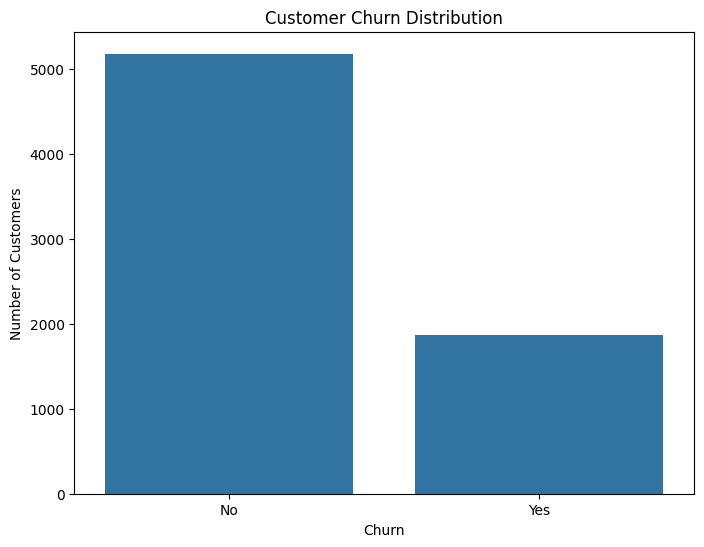

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x='Churn', data=Churn)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

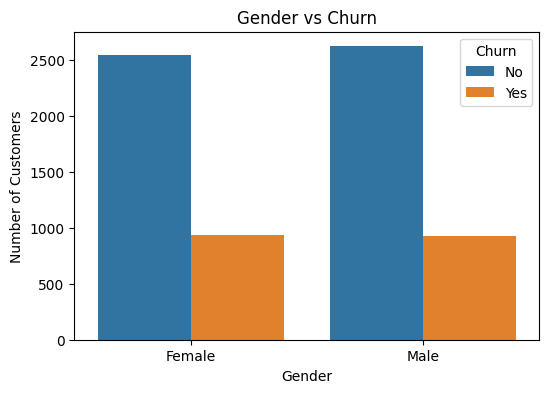

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='Churn', data=Churn)
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.title("Gender vs Churn")
plt.show()

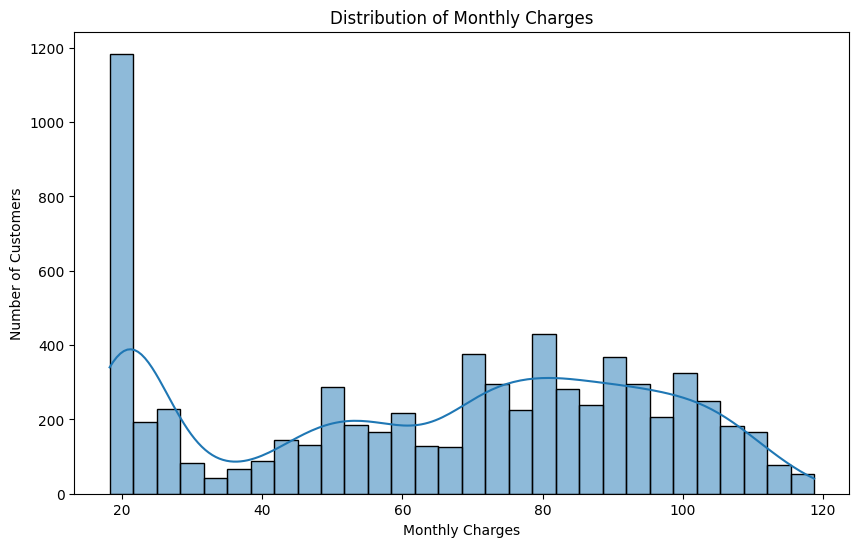

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(Churn['MonthlyCharges'], bins=30, kde=True)
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

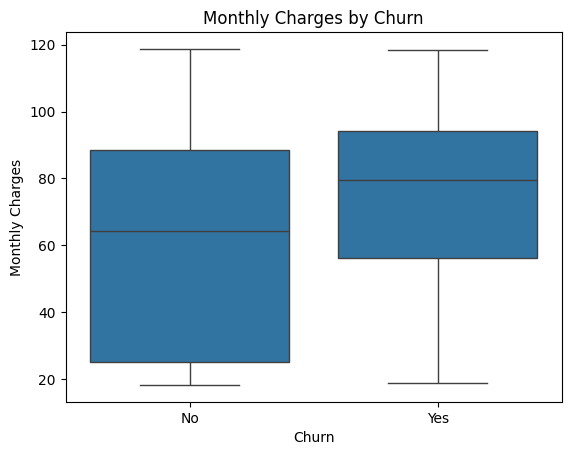

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=Churn)
plt.title('Monthly Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()


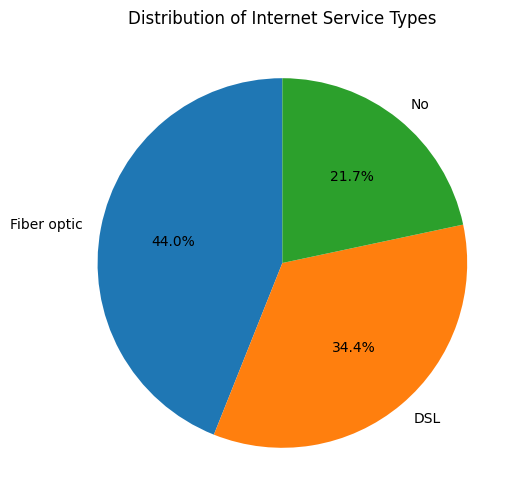

In [ ]:
internet_service_counts = Churn['InternetService'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(internet_service_counts, labels=internet_service_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Internet Service Types')
plt.ylabel('')
plt.show()

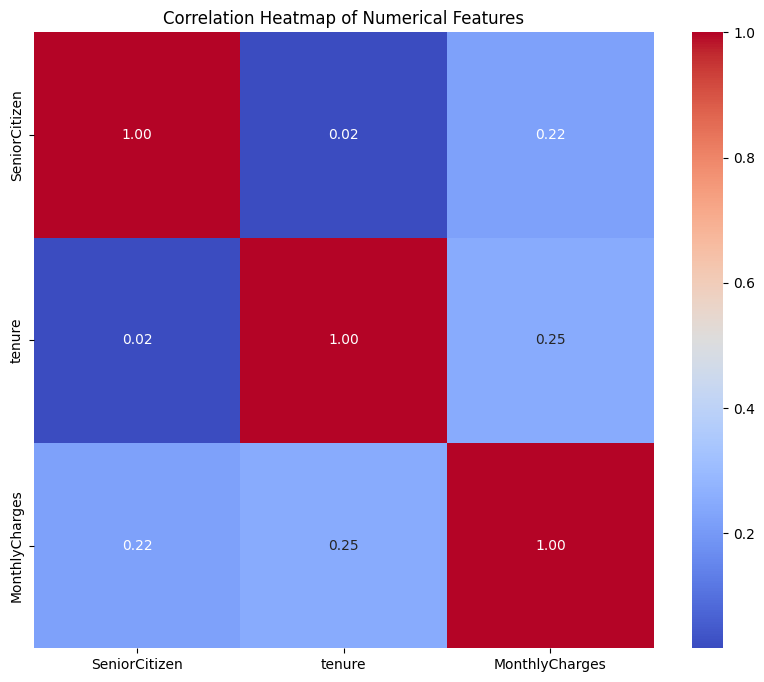

In [ ]:
numerical_cols = Churn.select_dtypes(include=['number']).columns
correlation_matrix = Churn[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

*Check Kurtosis*

In [ ]:
Churn['TotalCharges'] = pd.to_numeric(Churn['TotalCharges'], errors='coerce')

In [ ]:
Churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

Churn[numerical_cols].kurt()

,0
tenure,-1.387372
MonthlyCharges,-1.257260
TotalCharges,-0.231799


*check skewness*

In [ ]:
Churn[numerical_cols].skew()

,0
tenure,0.239540
MonthlyCharges,-0.220524
TotalCharges,0.961642


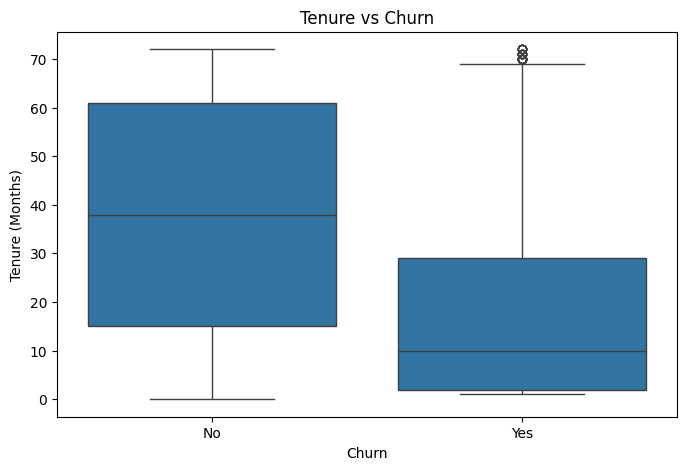

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='tenure', data=Churn)

plt.title('Tenure vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

In [ ]:
Churn.groupby('Churn')['tenure'].mean()

,tenure
Churn,
No,37.569965
Yes,17.979133


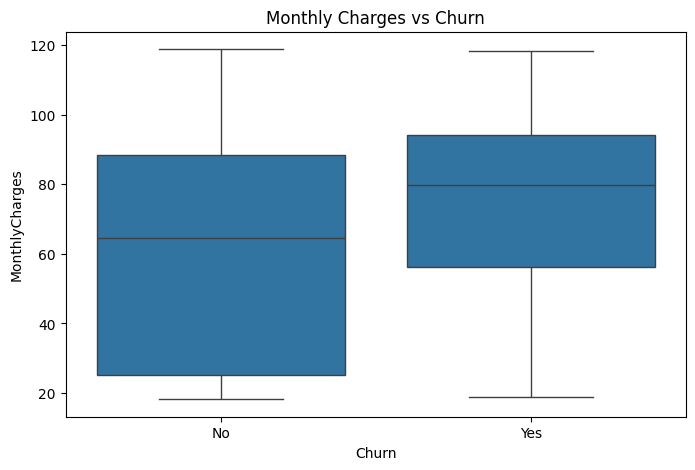

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=Churn)

plt.title('Monthly Charges vs Churn')
plt.show()

print(Churn.groupby('Churn')['MonthlyCharges'].mean())

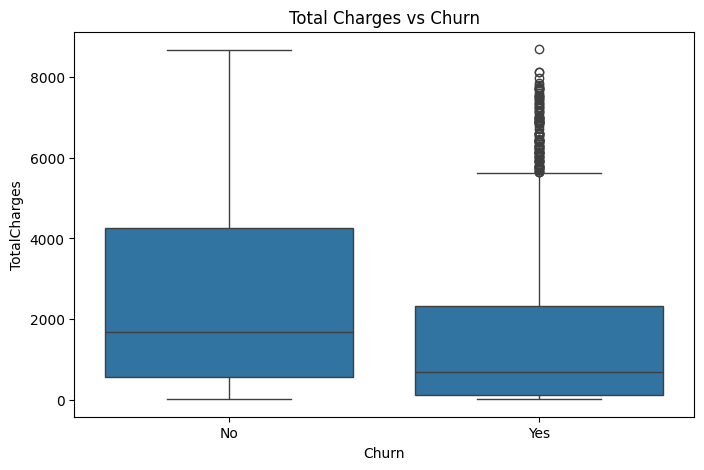

Churn
No     2555.344141
Yes    1531.796094
Name: TotalCharges, dtype: float64


In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='TotalCharges', data=Churn)

plt.title('Total Charges vs Churn')
plt.show()

print(Churn.groupby('Churn')['TotalCharges'].mean())

**Step 4:Data Preprocessing**

In [ ]:
Churn.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
Churn['TotalCharges'].isnull().sum()

np.int64(11)

In [ ]:
Q1 = Churn['TotalCharges'].quantile(0.25)
Q3 = Churn['TotalCharges'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = Churn[(Churn['TotalCharges'] < lower_bound) | (Churn['TotalCharges'] > upper_bound)]

print("Number of outliers:", len(outliers))

Number of outliers: 0


In [ ]:
Churn['TotalCharges']=Churn['TotalCharges'].fillna(Churn['TotalCharges'].median())

In [ ]:
Churn.duplicated().sum()

np.int64(22)

In [ ]:
Churn.drop_duplicates(inplace=True)

*Encoding..*

In [ ]:
print(Churn.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [ ]:
print(Churn['gender'].unique())

['Female' 'Male']


In [ ]:
print(Churn['Partner'].unique())

['Yes' 'No']


In [ ]:
print(Churn['Dependents'].unique())

['No' 'Yes']


In [ ]:
print(Churn['PhoneService'].unique())

['No' 'Yes']


In [ ]:
print(Churn['MultipleLines'].unique())

['No phone service' 'No' 'Yes']


In [ ]:
print(Churn['InternetService'].unique())

['DSL' 'Fiber optic' 'No']


In [ ]:
print(Churn['OnlineSecurity'].unique())

['No' 'Yes' 'No internet service']


In [ ]:
print(Churn['OnlineBackup'].unique())

['Yes' 'No' 'No internet service']


In [ ]:
print(Churn['DeviceProtection'].unique())

['No' 'Yes' 'No internet service']


In [ ]:
print(Churn['TechSupport'].unique())

['No' 'Yes' 'No internet service']


In [ ]:
print(Churn['StreamingTV'].unique())

['No' 'Yes' 'No internet service']


In [ ]:
print(Churn['StreamingMovies'].unique())

['No' 'Yes' 'No internet service']


In [ ]:
print(Churn['Contract'].unique())

['Month-to-month' 'One year' 'Two year']


In [ ]:
print(Churn['PaperlessBilling'].unique())


['Yes' 'No']


In [ ]:
print(Churn['PaymentMethod'].unique())

['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [ ]:
print(Churn['Churn'].unique())

['No' 'Yes']


*Easy method*

In [ ]:
for col in Churn.columns:
    print(f"\nColumn: {col}")
    print(Churn[col].unique())


Column: gender
['Female' 'Male']

Column: SeniorCitizen
[0 1]

Column: Partner
['Yes' 'No']

Column: Dependents
['No' 'Yes']

Column: tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]

Column: PhoneService
['No' 'Yes']

Column: MultipleLines
['No phone service' 'No' 'Yes']

Column: InternetService
['DSL' 'Fiber optic' 'No']

Column: OnlineSecurity
['No' 'Yes' 'No internet service']

Column: OnlineBackup
['Yes' 'No' 'No internet service']

Column: DeviceProtection
['No' 'Yes' 'No internet service']

Column: TechSupport
['No' 'Yes' 'No internet service']

Column: StreamingTV
['No' 'Yes' 'No internet service']

Column: StreamingMovies
['No' 'Yes' 'No internet service']

Column: Contract
['Month-to-month' 'One year' 'Two year']

Column: PaperlessBilling
['Yes' 'No']

Column: PaymentMethod
['Electronic check' 'M

In [ ]:
Churn['Partner']=Churn['Partner'].map({'Yes':1,'No':0})
Churn['Dependents']=Churn['Dependents'].map({'Yes':1,'No':0})
Churn['PhoneService']=Churn['PhoneService'].map({'Yes':1,'No':0})
Churn['PaperlessBilling']=Churn['PaperlessBilling'].map({'Yes':1,'No':0})
Churn['Churn']=Churn['Churn'].map({'Yes':1,'No':0})
Churn['gender']=le.fit_transform(Churn['gender'])


In [ ]:
Churn.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1


In [ ]:
Churn=pd.get_dummies(Churn,columns=['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod'],dtype='int64' )

In [ ]:
Churn.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,1,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,1,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,1,0,0,1,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,1,0,1,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,1,0,0,1,0,0,0,0,1,0


In [ ]:
Churn['TotalCharges']=sc.fit_transform(Churn[['TotalCharges']])
Churn['MonthlyCharges']=sc.fit_transform(Churn[['MonthlyCharges']])

In [ ]:
Churn.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,-1.164135,-0.997328,0,...,1,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,-0.262811,-0.176347,0,...,1,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,1,-0.365914,-0.962760,1,...,1,0,0,1,0,0,0,0,0,1


**Separate Features and Target**

In [ ]:
X = Churn.drop('Churn', axis=1)
y = Churn['Churn']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
import joblib

# Save the trained model
joblib.dump(model, "model.pkl")

# Save the scaler
joblib.dump(sc, "scaler.pkl")

# Save the column names
joblib.dump(X_train.columns.tolist(), "columns.pkl")

#save the encoder
joblib.dump(le, "encoder.pkl")

['encoder.pkl']

In [ ]:
import os
os.listdir()

['.config',
 'drive',
 'model.pkl',
 'columns.pkl',
 'scaler.pkl',
 'encoder.pkl',
 'sample_data']

In [ ]:
from google.colab import files

files.download("model.pkl")
files.download("scaler.pkl")
files.download("columns.pkl")
files.download("encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy*100)

Accuracy: 80.21352313167259


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.66      0.52      0.58       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.73      1405
weighted avg       0.79      0.80      0.79      1405



In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.7117437722419929
              precision    recall  f1-score   support

           0       0.82      0.79      0.80      1033
           1       0.46      0.51      0.48       372

    accuracy                           0.71      1405
   macro avg       0.64      0.65      0.64      1405
weighted avg       0.72      0.71      0.72      1405



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7814946619217081
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.62      0.47      0.53       372

    accuracy                           0.78      1405
   macro avg       0.72      0.68      0.69      1405
weighted avg       0.77      0.78      0.77      1405



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
kn=KNeighborsClassifier()
kn.fit(X_train,y_train)

KNeighborsClassifier()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_kn = kn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_kn))
print(classification_report(y_test, y_pred_kn))

Accuracy: 0.7558718861209964
              precision    recall  f1-score   support

           0       0.82      0.85      0.84      1033
           1       0.54      0.49      0.52       372

    accuracy                           0.76      1405
   macro avg       0.68      0.67      0.68      1405
weighted avg       0.75      0.76      0.75      1405



In [ ]:
from sklearn.svm import SVC
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.7850533807829182
              precision    recall  f1-score   support

           0       0.81      0.92      0.86      1033
           1       0.64      0.42      0.51       372

    accuracy                           0.79      1405
   macro avg       0.73      0.67      0.69      1405
weighted avg       0.77      0.79      0.77      1405



In [ ]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.6811387900355872
              precision    recall  f1-score   support

           0       0.91      0.62      0.74      1033
           1       0.45      0.84      0.58       372

    accuracy                           0.68      1405
   macro avg       0.68      0.73      0.66      1405
weighted avg       0.79      0.68      0.70      1405



In [ ]:
import joblib

joblib.dump(model, "customer_churn_model.pkl")

['customer_churn_model.pkl']

In [ ]:
joblib.dump(sc, "scaler.pkl")

['scaler.pkl']

In [ ]:
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'MultipleLines_No', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_DSL',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No',
       'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit 

In [ ]:
columns = X_train.columns.tolist()
joblib.dump(columns, "columns.pkl")

['columns.pkl']